# Ship Engine Anomaly Detection

Unsupervised anomaly detection on continuous sensor readings from a marine
propulsion engine — 19,535 cycles, six features (RPM, lube-oil pressure /
temperature, fuel pressure, coolant pressure / temperature). Three approaches
are compared: IQR-based statistical flagging, One-Class SVM, and Isolation
Forest. The comparison is the point — not "which model wins", but which set
of flags a fleet operator should actually act on.

## Problem framing

Unplanned engine downtime on a vessel at sea is one of the most expensive
failures in shipping: lost cargo time, towage, port re-routing, crew safety
risk. Continuous condition-monitoring data is cheap, and modern engines emit
plenty of it — but raw sensor traces are noisy and only a small fraction of
unusual readings are real issues. The operational question is therefore not
"are there outliers?" but **"can we surface a 1–5% shortlist that a chief
engineer should look at, with enough method-agreement that we are not flooding
them with false positives?"**

## Approach

1. EDA on six sensor channels — distributions, percentile cut-offs, the
   handful of obvious extremes (one coolant-temperature reading at 195 °C).
2. **IQR multivariate rule** — flag rows where ≥2 features are individually
   outside Tukey fences. Tuned the "≥k features" threshold so the flag rate
   lands in the 1–5% band a fleet operator can triage.
3. **One-Class SVM** (RBF) — hyperparameter sweep over `gamma` and `nu` to
   land in the same 1–5% band; PCA projection for visual inspection.
4. **Isolation Forest** — contamination set to 5% with 500 trees; same PCA
   overlay for like-for-like comparison.
5. **Method agreement** — pairwise and three-way overlap between the three
   flag sets. The intersection (1.2% of rows) is the high-confidence shortlist.

## Headline result

Isolation Forest and One-Class SVM agree on **~89%** of their flagged rows —
strong signal that both are locking onto the same underlying anomalous
patterns. IQR is the noisiest — 39% agreement with One-Class SVM — because
single-feature outliers do not always reflect multivariate abnormality.

For deployment, **the three-way intersection (233 rows, 1.2%)** is the right
shortlist to escalate, with Isolation Forest as the day-to-day model because
it is robust to feature scaling and trains quickly.


# **Initial data evaluation**

***Import the required libraries and dataset***

In [44]:
# Import the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest

# Mute warnings.
import warnings
warnings.filterwarnings('ignore')


In [45]:
# Import tha dataset
url = 'https://raw.githubusercontent.com/fourthrevlxd/cam_dsb/main/engine.csv'
df = pd.read_csv(url)

***View the Dataframe***

In [46]:
# View the first 10 rows of the dataset
df.head(10).round(2)

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
0,682,2.39,4.62,2.85,76.27,69.88
1,605,5.47,6.42,5.73,73.22,74.91
2,658,3.43,3.68,1.68,88.09,78.70
3,749,2.09,7.12,1.64,77.66,82.39
4,676,3.54,5.96,3.23,75.23,67.15
5,589,2.93,6.36,2.46,77.53,75.40
6,885,2.03,15.50,1.52,78.96,80.82
7,576,5.50,13.11,1.25,78.09,71.93
8,535,3.16,8.68,1.27,82.41,80.75
9,806,3.95,21.14,1.57,74.92,72.11


***EDA***

In [47]:
# Check the size of the dataset (rows,columns)
df.shape


(19535, 6)

In [48]:
# Check the structure of the dataset and the data type of each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19535 entries, 0 to 19534
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Engine rpm        19535 non-null  int64  
 1   Lub oil pressure  19535 non-null  float64
 2   Fuel pressure     19535 non-null  float64
 3   Coolant pressure  19535 non-null  float64
 4   lub oil temp      19535 non-null  float64
 5   Coolant temp      19535 non-null  float64
dtypes: float64(5), int64(1)
memory usage: 915.8 KB


The dataset contains multiple sensor readings from a Ship's engine.
The variables represent the engine's RPM, different pressures (Lubricating oil, Fuel, Coolant) and temperatures (Lubricating oil, Coolant).

All values are numerical.

The dataset has 19535 rows and 6 columns (features).

**Data types:**

Engine - *integer*, Pressure (Lub oil, Fuel, Coolant) - *Float*, Temperature (Lub oil, Coolant) - *Float*

In [49]:
# Find the missing values in the dataset
df.isnull().sum()

,0
Engine rpm,0
Lub oil pressure,0
Fuel pressure,0
Coolant pressure,0
lub oil temp,0
Coolant temp,0


No missing values

In [50]:
# Find the duplicate values in the dataset
df.duplicated().sum()

np.int64(0)

No duplicates

In [51]:
# Check the descriptive statistics of the dataset
df.describe().round(2)

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
count,19535.00,19535.00,19535.00,19535.00,19535.00,19535.00
mean,791.24,3.30,6.66,2.34,77.64,78.43
std,267.61,1.02,2.76,1.04,3.11,6.21
min,61.00,0.00,0.00,0.00,71.32,61.67
25%,593.00,2.52,4.92,1.60,75.73,73.90
50%,746.00,3.16,6.20,2.17,76.82,78.35
75%,934.00,4.06,7.74,2.85,78.07,82.92
max,2239.00,7.27,21.14,7.48,89.58,195.53


In [52]:
# Identify the range values beyond the 95th percentile
df.quantile(0.95).round(2)



,0.95
Engine rpm,1324.00
Lub oil pressure,5.06
Fuel pressure,12.21
Coolant pressure,4.44
lub oil temp,84.94
Coolant temp,88.61


**Visualise the data**

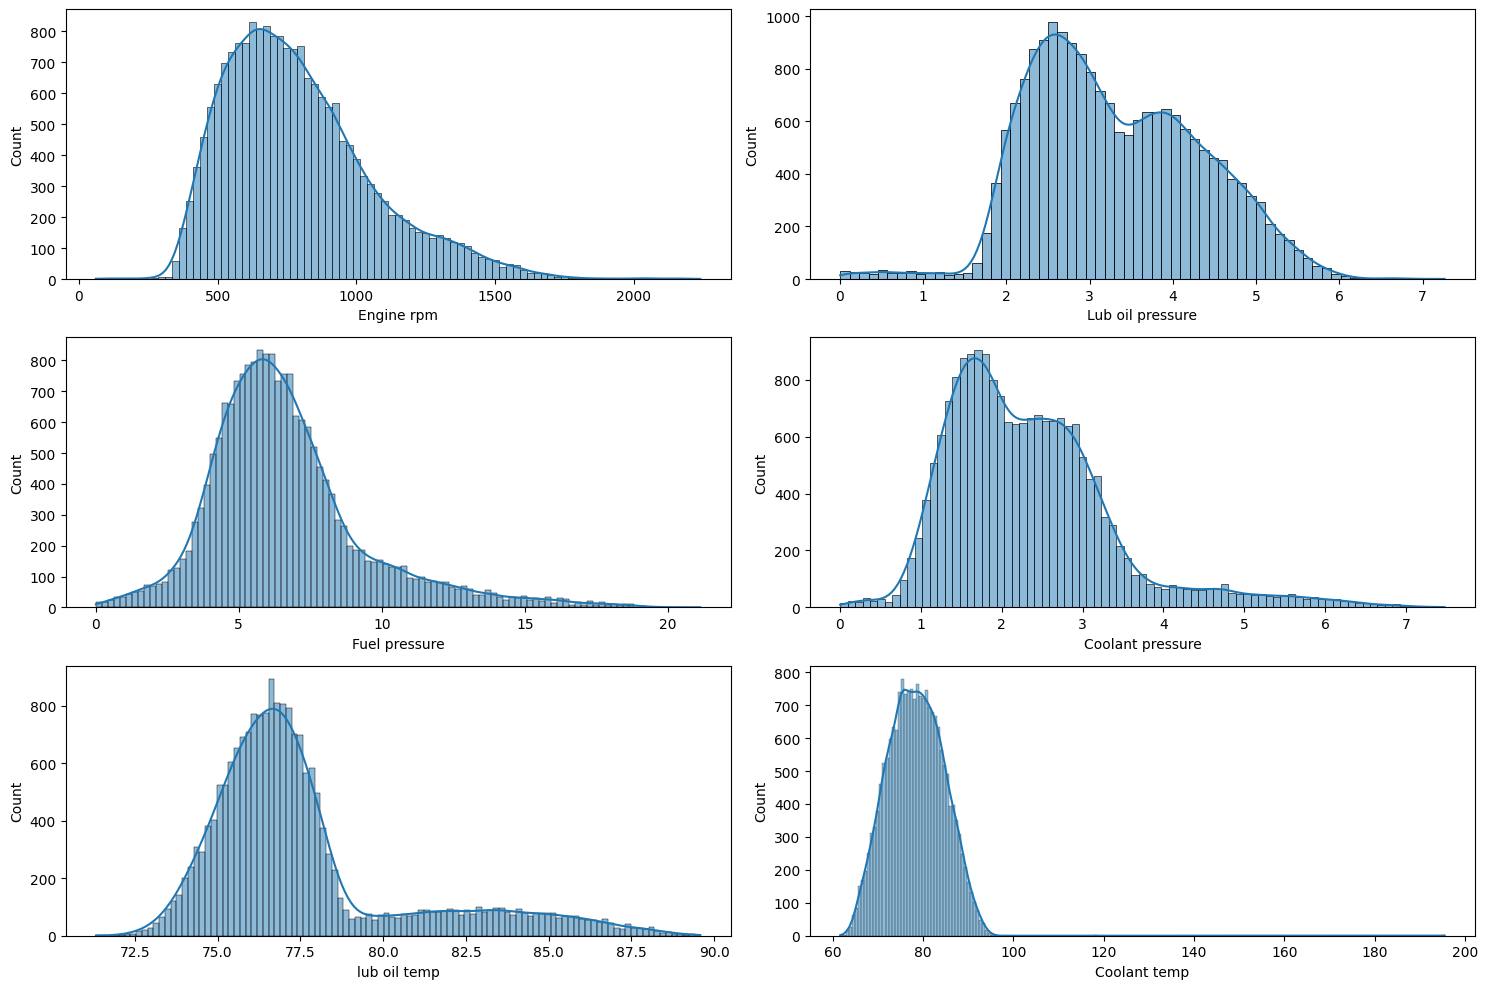

In [53]:
# Visualise using 6 histogram plots for all 6 columns
plt.figure(figsize=(15,10))

# Histogram of all 6 columns
plt.subplot(3,2,1)
sns.histplot(df['Engine rpm'], kde=True)

# Do the same for other columns
plt.subplot(3,2,2)
sns.histplot(df['Lub oil pressure'], kde=True)

plt.subplot(3,2,3)
sns.histplot(df['Fuel pressure'], kde=True)

plt.subplot(3,2,4)
sns.histplot(df['Coolant pressure'], kde=True)

plt.subplot(3,2,5)
sns.histplot(df['lub oil temp'], kde=True)

plt.subplot(3,2,6)
sns.histplot(df['Coolant temp'], kde=True)

plt.tight_layout()
plt.show()


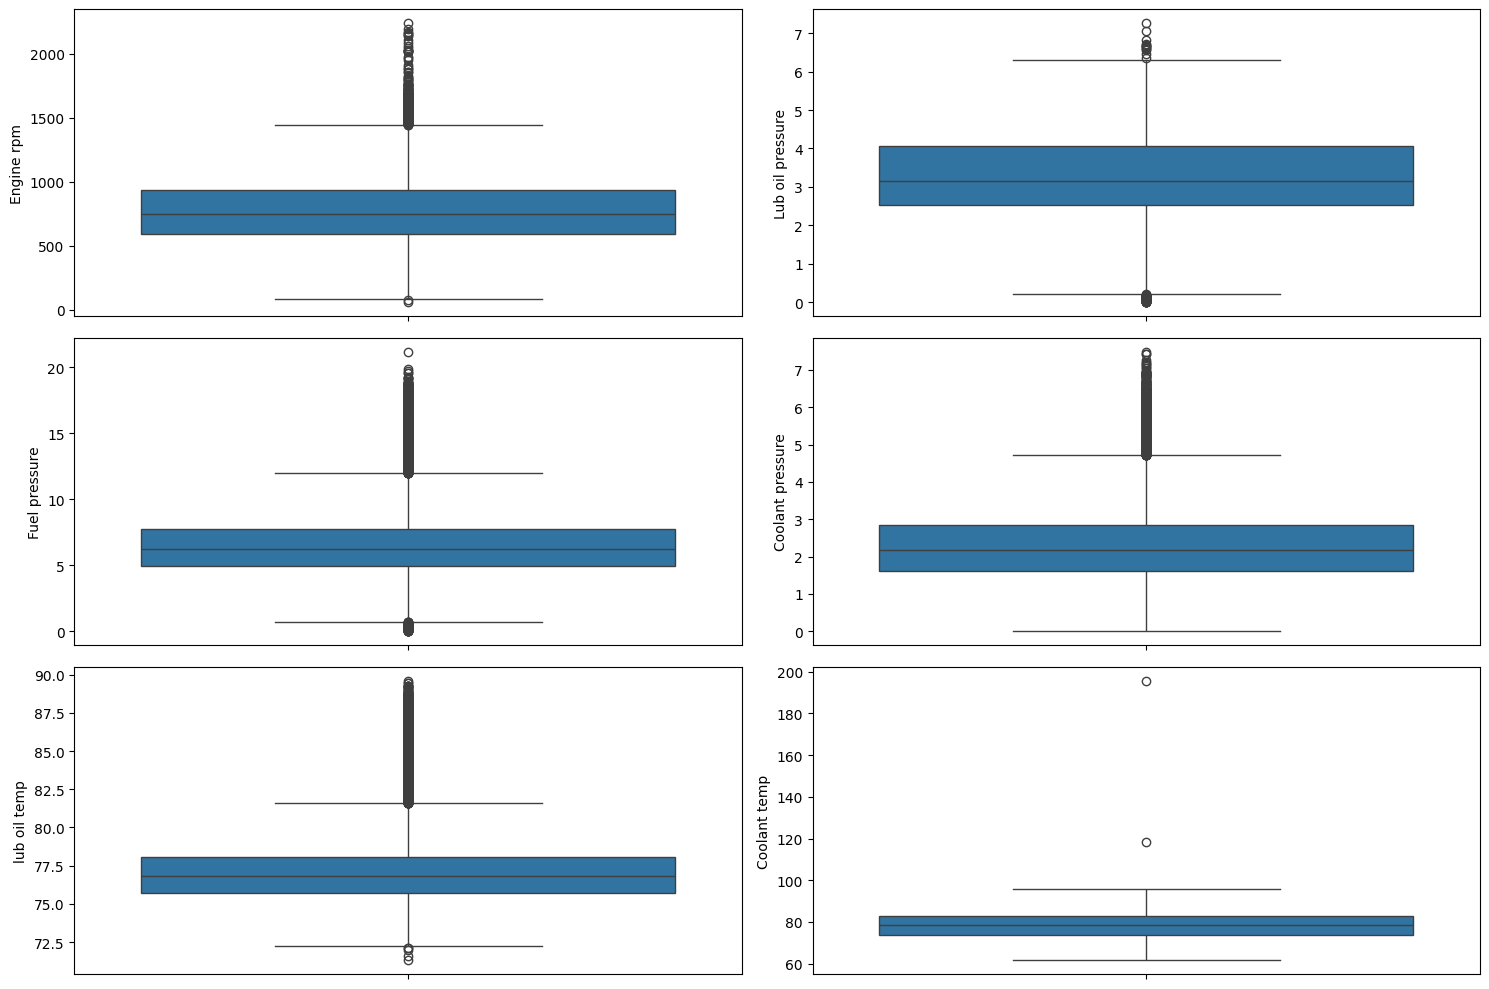

In [54]:
# Visualise using 6 box plots for all 6 columns
plt.figure(figsize=(15,10))

# Box plot of all 6 columns
plt.subplot(3,2,1)
sns.boxplot(df['Engine rpm'])

# Do the same for other columns
plt.subplot(3,2,2)
sns.boxplot(df['Lub oil pressure'])

plt.subplot(3,2,3)
sns.boxplot(df['Fuel pressure'])

plt.subplot(3,2,4)
sns.boxplot(df['Coolant pressure'])

plt.subplot(3,2,5)
sns.boxplot(df['lub oil temp'])

plt.subplot(3,2,6)
sns.boxplot(df['Coolant temp'])

plt.tight_layout()
plt.show()

# **Summary of EDA**


Most features show consistent central tendencies.

**Engine RPM** ranging between 61-2239 and a median of 746, suggests frequent low-speed running. However the gap between 95th percentile value and max value suggests a few spikes that need closer attention.

**Lubricating oil and Coolant temperatures** range between 71-82 degrees for most of the data. However, for Coolant temp- 95% of the values fall below 88 degrees, so only 5% of readings exceed beyond that value and since the maximum temp reached is 195 degrees - these are the high temp events that needs investigating.

**Lubricating oil, Fuel and Coolant pressures** range between near-zero and go upto the mean values for 75% of the data. However, for fuel pressure - 95% of the values fall below 12 units and 5% above this threshold are the values that need closer inspection (since the max value recorded is 21)

***Note:***
All temperature and pressure values show occasional spikes which may indicate inefficient operational events or sensor inaccuracies.


## **Interpretation of the plots**



**Engine rpm** is right-skewed, peaking around 600 rpm, with occasional high-rpm outliers — suggesting consistent overall cruising.

**Lubricating oil pressure** shows a bimodal distribution, indicating two operating loads and a few low and high - pressure anomalies.

**Fuel pressure** is moderately right-skewed but with high-pressure outliers that may reflect fuel-injector issues or load shifts.

**Coolant pressure** is right skewed with tail gradually tapering off towards higher pressure values, Outliers visible in the box-plots indicates high-pressure values that could mean cooling system issues, sensor data irregularities etc.

**Lubricating oil temperature** displays a right-skewed distribution with long tail towards higher temperatures, reflecting over-heating, poor lubrication flow etc. Outliers could signal wear or cooling systemn issues.

**Coolant temperature** is highly consistent around 80 degrees celsius, but two extreme outliers (one at 120 and other around 200 degrees) suggest potential overheating or sensor faults.


Overall, the system seems to be showing healthy operating patterns. The presence of outliers needs investigation but it doesn't seem to lead to any system failure.

# **Anomaly detection using Statistical method (IQR)**

In [55]:
# Create the dataframe for IQR model
df_IQR = df.copy()
df_IQR.head()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
0,682,2.391656,4.617196,2.848982,76.272417,69.884609
1,605,5.466877,6.424361,5.727520,73.222679,74.907314
2,658,3.434232,3.680896,1.678708,88.089916,78.704806
3,749,2.094656,7.120927,1.639670,77.661625,82.386700
4,676,3.538228,5.956472,3.225336,75.226352,67.153220


In [56]:
# Show the list of columns

columns = df_IQR.columns
print(columns)

Index(['Engine rpm', 'Lub oil pressure', 'Fuel pressure', 'Coolant pressure',
       'lub oil temp', 'Coolant temp'],
      dtype='object')


In [57]:

# Loop through all columns and  create flagged columns for outliers

for col in columns:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_limit = Q1 - 1.5 * IQR
  upper_limit = Q3 + 1.5 * IQR
  df[col + '_flagged'] = ((df[col] < lower_limit) | (df[col] > upper_limit)).astype(int)


# View the first 10 rows of the dataset
df.head()


,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine rpm_flagged,Lub oil pressure_flagged,Fuel pressure_flagged,Coolant pressure_flagged,lub oil temp_flagged,Coolant temp_flagged
0,682,2.391656,4.617196,2.848982,76.272417,69.884609,0,0,0,0,0,0
1,605,5.466877,6.424361,5.727520,73.222679,74.907314,0,0,0,1,0,0
2,658,3.434232,3.680896,1.678708,88.089916,78.704806,0,0,0,0,1,0
3,749,2.094656,7.120927,1.639670,77.661625,82.386700,0,0,0,0,0,0
4,676,3.538228,5.956472,3.225336,75.226352,67.153220,0,0,0,0,0,0


In [58]:
# Identify all flagged columns
flagged_columns = [col for col in df.columns if '_flagged' in col]

# Create a new column for rows where two or more features are flagged ==1
df['IQR_preds'] = (df[flagged_columns].sum(axis=1) >= 2).astype(int)

# Show only rows with anomalies
df_anomaly = df[df['IQR_preds'] == 1]

df_anomaly.shape

(422, 13)

In [59]:
# View the first 10 rows
df_anomaly.head(10)

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine rpm_flagged,Lub oil pressure_flagged,Fuel pressure_flagged,Coolant pressure_flagged,lub oil temp_flagged,Coolant temp_flagged,IQR_preds
113,1495,3.276230,3.714396,2.495264,85.053243,75.743004,1,0,0,0,1,0,1
122,1454,2.063374,6.168260,1.260121,83.372256,82.718247,1,0,0,0,1,0,1
131,830,3.231908,13.479172,2.568096,87.480362,73.428213,0,0,1,0,1,0,1
144,1762,1.697487,4.327845,2.523372,86.750349,82.393211,1,0,0,0,1,0,1
148,1494,2.443220,3.548139,1.953403,82.234541,83.953914,1,0,0,0,1,0,1
157,534,5.922045,18.044686,5.946436,77.292791,74.734372,0,0,1,1,0,0,1
160,1546,3.903522,6.205256,5.554939,78.825641,73.677703,1,0,0,1,0,0,1
249,1004,2.745963,16.554492,5.738463,74.621543,83.155235,0,0,1,1,0,0,1
260,1378,2.099323,5.522725,5.522853,84.682532,80.888281,0,0,0,1,1,0,1
313,647,3.202703,4.658130,6.095645,82.628419,66.322430,0,0,0,1,1,0,1


In [60]:
# Identify the features with the highest number of anomalies
anomaly_counts = df_anomaly[flagged_columns].sum()
print(anomaly_counts)

Engine rpm_flagged          112
Lub oil pressure_flagged     18
Fuel pressure_flagged       217
Coolant pressure_flagged    171
lub oil temp_flagged        337
Coolant temp_flagged          0
dtype: int64


In [61]:
# Identify the number of features such that the total percentage of anomalies falls within the 1-5% range

total_rows = len(df)

for i in range(1, len(flagged_columns)+1):
    outlier_rows = df[df[flagged_columns].sum(axis=1) >= i]
    percentage = len(outlier_rows) / total_rows * 100
    print(f"If ≥ {i} features are flagged → {percentage:.2f}% of rows are outliers")


If ≥ 1 features are flagged → 23.73% of rows are outliers
If ≥ 2 features are flagged → 2.16% of rows are outliers
If ≥ 3 features are flagged → 0.06% of rows are outliers
If ≥ 4 features are flagged → 0.00% of rows are outliers
If ≥ 5 features are flagged → 0.00% of rows are outliers
If ≥ 6 features are flagged → 0.00% of rows are outliers


# **Observations**

Using the IQR method to detect outliers, each row was assessed on how many features were flagged as outliers. The goal was to keep the proportion of flagged rows within a reasonable 1-5% range.

The analysis showed that using a threshold of **2 or more** flagged features resulted in 2.16% of rows being classified as outliers, which is within the range considered.

Lubricating Oil temperature and Fuel pressure were identified as the features with the highest number of anomalies.





# **Anomaly detection using one-class SVM**

In [62]:
# Select the columns to be used for one-class SVM

features = ['Engine rpm', 'Lub oil pressure', 'Fuel pressure', 'Coolant pressure', 'lub oil temp','Coolant temp' ]

# View the table
df[features].head()


,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
0,682,2.391656,4.617196,2.848982,76.272417,69.884609
1,605,5.466877,6.424361,5.727520,73.222679,74.907314
2,658,3.434232,3.680896,1.678708,88.089916,78.704806
3,749,2.094656,7.120927,1.639670,77.661625,82.386700
4,676,3.538228,5.956472,3.225336,75.226352,67.153220


In [63]:
# Scale the data
scaler = StandardScaler()
df[features] = scaler.fit_transform(df[features])

# View the table
df[features].head()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
0,-0.408212,-0.892819,-0.738304,0.495596,-0.440709,-1.376412
1,-0.695950,2.117332,-0.083759,3.273154,-1.421047,-0.567158
2,-0.497896,0.127697,-1.077426,-0.633625,3.358026,0.044690
3,-0.157842,-1.183534,0.168533,-0.671293,0.005852,0.637913
4,-0.430633,0.229492,-0.253226,0.858747,-0.776966,-1.816491


In [64]:
# Specify the model
model_svm = OneClassSVM(kernel='rbf', gamma=0.1, nu=0.05)

# Train the model
model_svm.fit(df[features])

# Predict normal or anomalies
df['svm_preds'] = model_svm.predict(df[features])
print(df['svm_preds'])

0        1
1       -1
2        1
3        1
4        1
        ..
19530    1
19531    1
19532    1
19533    1
19534    1
Name: svm_preds, Length: 19535, dtype: int64


In [65]:
# Create dataframe for convenience
df_OCSVM = df[features + ['svm_preds']]

# View the table
df_OCSVM.head()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,svm_preds
0,-0.408212,-0.892819,-0.738304,0.495596,-0.440709,-1.376412,1
1,-0.695950,2.117332,-0.083759,3.273154,-1.421047,-0.567158,-1
2,-0.497896,0.127697,-1.077426,-0.633625,3.358026,0.044690,1
3,-0.157842,-1.183534,0.168533,-0.671293,0.005852,0.637913,1
4,-0.430633,0.229492,-0.253226,0.858747,-0.776966,-1.816491,1


In [66]:
# Display outliers in the dataframe
anomalies_OCSVM = df_OCSVM[df_OCSVM['svm_preds'] == -1]

# View the table
anomalies_OCSVM

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,svm_preds
1,-0.695950,2.117332,-0.083759,3.273154,-1.421047,-0.567158,-1
9,0.055159,0.629502,5.245553,-0.736041,-0.874377,-1.017425,-1
17,1.946010,2.603387,0.328859,3.470415,0.030684,1.648979,-1
115,-2.728802,0.619474,0.518973,-0.473084,-0.133790,-0.699133,-1
144,3.627597,-1.572300,-0.843105,0.181408,2.927422,0.638962,-1
...,...,...,...,...,...,...,...
19370,-0.191474,-0.500402,1.703548,-0.728687,3.583673,-1.350141,-1
19375,0.776373,-3.109890,-0.561144,1.546654,-0.963731,2.243787,-1
19433,0.727794,-0.366638,2.816375,2.556936,-0.696229,-1.388626,-1
19467,1.975905,-1.012180,2.861838,-0.856781,-0.650319,-0.691550,-1


In [67]:
# Calculate the percentage of anomalies

percentage = len(anomalies_OCSVM) / len(df_OCSVM) * 100
print(f"Percentage of anomalies: {percentage:.2f}%")

Percentage of anomalies: 5.01%


In [68]:
# Trying different combinations of gamma and nu

for gamma in [0.1, 0.2, 0.3,0.4,0.5]:
    for nu in [0.01, 0.02, 0.03, 0.04, 0.05]:
        model_svm = OneClassSVM(kernel='rbf', gamma=gamma, nu=nu)
        model_svm.fit(df[features])
        df['svm_preds'] = model_svm.predict(df[features])
        anomalies_OCSVM = df[df['svm_preds'] == -1]
        percentage = len(anomalies_OCSVM) / len(df) * 100
        num_anomalies = len(anomalies_OCSVM)
        print(f"Gamma: {gamma}, Nu: {nu}, Percentage of anomalies: {percentage:.2f}%, Number of anomalies: {len(anomalies_OCSVM)}")

Gamma: 0.1, Nu: 0.01, Percentage of anomalies: 0.97%, Number of anomalies: 189
Gamma: 0.1, Nu: 0.02, Percentage of anomalies: 2.01%, Number of anomalies: 392
Gamma: 0.1, Nu: 0.03, Percentage of anomalies: 3.00%, Number of anomalies: 586
Gamma: 0.1, Nu: 0.04, Percentage of anomalies: 4.01%, Number of anomalies: 783
Gamma: 0.1, Nu: 0.05, Percentage of anomalies: 5.01%, Number of anomalies: 978
Gamma: 0.2, Nu: 0.01, Percentage of anomalies: 1.03%, Number of anomalies: 202
Gamma: 0.2, Nu: 0.02, Percentage of anomalies: 1.99%, Number of anomalies: 389
Gamma: 0.2, Nu: 0.03, Percentage of anomalies: 3.02%, Number of anomalies: 590
Gamma: 0.2, Nu: 0.04, Percentage of anomalies: 4.04%, Number of anomalies: 790
Gamma: 0.2, Nu: 0.05, Percentage of anomalies: 5.03%, Number of anomalies: 983
Gamma: 0.3, Nu: 0.01, Percentage of anomalies: 1.41%, Number of anomalies: 275
Gamma: 0.3, Nu: 0.02, Percentage of anomalies: 2.22%, Number of anomalies: 433
Gamma: 0.3, Nu: 0.03, Percentage of anomalies: 3.02%

In [69]:
# Selecting the moderate values of gamma and nu to be in the expected outlier range of 1-5%
# gamma = 0.1 , nu = 0.05

model_svm = OneClassSVM(kernel='rbf', gamma=0.1, nu=0.05)
model_svm.fit(df[features])
df['svm_preds'] = model_svm.predict(df[features])
anomalies_OCSVM = df[df['svm_preds'] == -1]
percentage = len(anomalies_OCSVM) / len(df) * 100
print(f"Percentage of anomalies: {percentage:.2f}%")

Percentage of anomalies: 5.01%


In [70]:
# Calculating the overlap between one-class SVM and IQR outliers

# Convert OCSVM outlier values to binary
df['svm_binary'] = (df['svm_preds'] == -1).astype(int)

# Adding svm_binary into the dataframe
anomalies_OCSVM = df[df['svm_binary'] == 1]

# Compare the overlap
df['overlap'] = ((df['IQR_preds'] == 1) & (df['svm_binary'] == 1)).astype(int)

# Count the number of overlaps
num_overlaps = df[df['overlap'] == 1].shape[0]
print(f"Number of overlaps: {num_overlaps}")


Number of overlaps: 233


In [71]:
# Visualising the output of outliers in 2D space

# Using PCA to reduce the dimensionality of the data
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df[features])

# Add the PCA results to the dataframe
df['PC1'] = pca_result[:, 0]
df['PC2'] = pca_result[:, 1]

In [72]:
# View the PCA values
df[['PC1', 'PC2']].head()

,PC1,PC2
0,-0.557362,-0.906512
1,-2.177170,-1.201538
2,2.051806,1.039581
3,0.744375,-0.501140
4,-1.629821,-0.473906


In [73]:
# Create svm_label column
df['svm_labels'] = df['svm_preds'].map({1: 'Normal', -1: 'Anomaly'})

# Merge PCA values with the predicted values from OCSVM
df_OCSVM_PCA = pd.merge(df['svm_labels'], df[['PC1', 'PC2']], left_index=True, right_index=True)

# View the table
df_OCSVM_PCA.head()

,svm_labels,PC1,PC2
0,Normal,-0.557362,-0.906512
1,Anomaly,-2.177170,-1.201538
2,Normal,2.051806,1.039581
3,Normal,0.744375,-0.501140
4,Normal,-1.629821,-0.473906


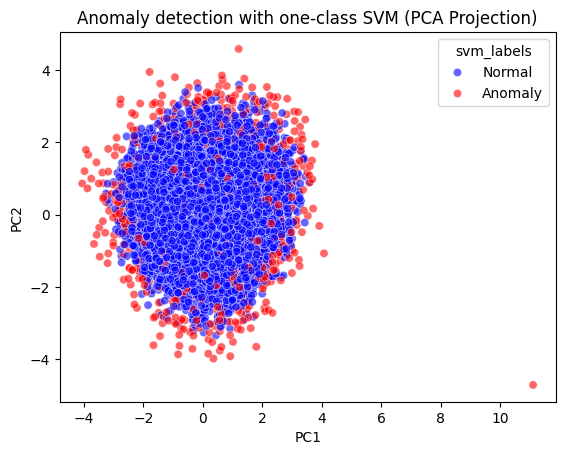

In [74]:
# Plot anomalies vs normal

sns.scatterplot(x='PC1', y='PC2', hue='svm_labels', data=df_OCSVM_PCA, palette={'Normal': 'blue', 'Anomaly': 'red'}, alpha=0.6)
plt.title('Anomaly detection with one-class SVM (PCA Projection)')
plt.show()

# **Observations**

One-class SVM Model learns the boundaries of normal data in a high-dimensional space. The models performance is highly dependent on gamma and nu inputs. I experimented with multiple combinations of these inputs and observed that small changes in these values significantlyt affect the proportion of anomalies detected.

978 anomalies were detected using this method.

I observed that the overlap between One-class SVM and IQR-based outliers was about 39% (163/422) which indicates that One-class SVM is in about 39% agreement with IQR model in regards to the outliers flagged. This could possibly be because the excess outliers in IQR model might not be anomalous when considering all features together.

Projecting the data into 2D space using PCA helped visualise the seperation between normal points and anomalies. Anomalies typically were scattered around the cluster of normal data, which again shows the models capability to isolate outliers.


# **Anomaly detection using Isolation forest**

In [75]:
# Select the raw original data
url = 'https://raw.githubusercontent.com/fourthrevlxd/cam_dsb/main/engine.csv'
df_IForest = pd.read_csv(url)

# View the table
df_IForest.head()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
0,682,2.391656,4.617196,2.848982,76.272417,69.884609
1,605,5.466877,6.424361,5.727520,73.222679,74.907314
2,658,3.434232,3.680896,1.678708,88.089916,78.704806
3,749,2.094656,7.120927,1.639670,77.661625,82.386700
4,676,3.538228,5.956472,3.225336,75.226352,67.153220


In [76]:
# Specify the model parameters (Contamination / range of anomalies considered is 5%)
model_IForest = IsolationForest(n_estimators=500, contamination=0.05, random_state=42)

# Train the model
model_IForest.fit(df_IForest[features])

# Predict normal or anomalies
df_IForest['IF_preds'] = model_IForest.predict(df_IForest[features])

# Print the anomalies
print(df_IForest['IF_preds'])

0        1
1       -1
2        1
3        1
4        1
        ..
19530    1
19531    1
19532    1
19533    1
19534    1
Name: IF_preds, Length: 19535, dtype: int64


In [77]:
# Create dataframe for conveniene
df_IForest = df_IForest[features + ['IF_preds']]

# View the table
df_IForest.head()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,IF_preds
0,682,2.391656,4.617196,2.848982,76.272417,69.884609,1
1,605,5.466877,6.424361,5.727520,73.222679,74.907314,-1
2,658,3.434232,3.680896,1.678708,88.089916,78.704806,1
3,749,2.094656,7.120927,1.639670,77.661625,82.386700,1
4,676,3.538228,5.956472,3.225336,75.226352,67.153220,1


In [78]:
# View the anomalies along with the table
anomalies_IForest = df_IForest[df_IForest['IF_preds'] == -1]
anomalies_IForest



,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,IF_preds
1,605,5.466877,6.424361,5.727520,73.222679,74.907314,-1
17,1312,5.963439,7.563578,5.931953,77.738876,88.661972,-1
35,1374,2.543575,8.641020,1.541131,82.268575,66.810303,-1
113,1495,3.276230,3.714396,2.495264,85.053243,75.743004,-1
131,830,3.231908,13.479172,2.568096,87.480362,73.428213,-1
...,...,...,...,...,...,...,...
19343,1475,2.184002,6.558549,1.265442,84.933480,88.088609,-1
19370,740,2.792556,11.359028,1.580190,88.791884,70.047659,-1
19375,999,0.126660,5.106325,3.938253,74.645346,92.353698,-1
19418,1536,4.775813,10.211842,2.118696,81.400970,83.649940,-1


In [79]:
# Check the size of the anomalies
anomalies_IForest.shape

(977, 7)

In [80]:
# Trying different combinations of contamination and n_estimators
for contamination in [0.01, 0.05, 0.1]:
    for n_estimators in [100, 500, 1000]:
        model_IForest = IsolationForest(n_estimators=n_estimators, contamination=contamination, random_state=42)
        model_IForest.fit(df_IForest[features])
        df_IForest['IF_preds'] = model_IForest.predict(df_IForest[features])
        anomalies_IForest = df_IForest[df_IForest['IF_preds'] == -1]
        percentage = len(anomalies_IForest) / len(df_IForest) * 100
        print(f"Contamination: {contamination}, n_estimators: {n_estimators}, Percentage of anomalies: {percentage:.2f}%")

Contamination: 0.01, n_estimators: 100, Percentage of anomalies: 1.00%
Contamination: 0.01, n_estimators: 500, Percentage of anomalies: 1.00%
Contamination: 0.01, n_estimators: 1000, Percentage of anomalies: 1.00%
Contamination: 0.05, n_estimators: 100, Percentage of anomalies: 5.00%
Contamination: 0.05, n_estimators: 500, Percentage of anomalies: 5.00%
Contamination: 0.05, n_estimators: 1000, Percentage of anomalies: 5.00%
Contamination: 0.1, n_estimators: 100, Percentage of anomalies: 10.00%
Contamination: 0.1, n_estimators: 500, Percentage of anomalies: 10.00%
Contamination: 0.1, n_estimators: 1000, Percentage of anomalies: 10.00%


In [81]:
# Compute overlap between anomalies in One-class SVM and IForest

# First convert IF_preds to binary values
anomalies_IForest['IF_binary'] = (anomalies_IForest['IF_preds'] == -1).astype(int)
anomalies_IForest

# Compute the overlap
anomalies_IForest['overlap'] = ((anomalies_IForest['IF_binary'] == 1) & (anomalies_OCSVM['svm_binary'] == 1)).astype(int)

# Count the number of overlaps
num_overlaps = len(anomalies_IForest[anomalies_IForest['overlap'] == 1])

# Print the number of overlaps
print(f"The number of overlaps between anomalies in One-class SVM and IForest is: {num_overlaps}")




The number of overlaps between anomalies in One-class SVM and IForest is: 868


In [82]:
# Compute overlap between anomalies in IQR and IForest

anomalies_IForest['overlap_IQR_IForest'] = ((anomalies_IForest['IF_binary'] == 1) & (df_anomaly['IQR_preds'] == 1)).astype(int)

# Count the number of overlaps
num_overlaps = len(anomalies_IForest[anomalies_IForest['overlap_IQR_IForest'] == 1])

# Print the number of overlaps
print(f"The number of overlaps between anomalies in IQR and IForest is: {num_overlaps}")

The number of overlaps between anomalies in IQR and IForest is: 393


In [83]:
# Getting the same PCA data from PCA performed for One-class SVM
df[['PC1', 'PC2']].head()


,PC1,PC2
0,-0.557362,-0.906512
1,-2.177170,-1.201538
2,2.051806,1.039581
3,0.744375,-0.501140
4,-1.629821,-0.473906


In [84]:
# Create IF_label column
df_IForest['IF_labels'] = df_IForest['IF_preds'].map({1: 'Normal', -1: 'Anomaly'})

# Merge PCA values with the predicted values from IForest
df_IForest_PCA = pd.merge(df_IForest['IF_labels'], df[['PC1', 'PC2']], left_index=True, right_index=True)

# View the table
df_IForest_PCA

,IF_labels,PC1,PC2
0,Normal,-0.557362,-0.906512
1,Anomaly,-2.177170,-1.201538
2,Normal,2.051806,1.039581
3,Normal,0.744375,-0.501140
4,Normal,-1.629821,-0.473906
...,...,...,...
19530,Normal,-1.311939,0.618409
19531,Normal,1.134547,-1.012464
19532,Normal,-0.832383,-2.159267
19533,Normal,1.126286,-0.051473


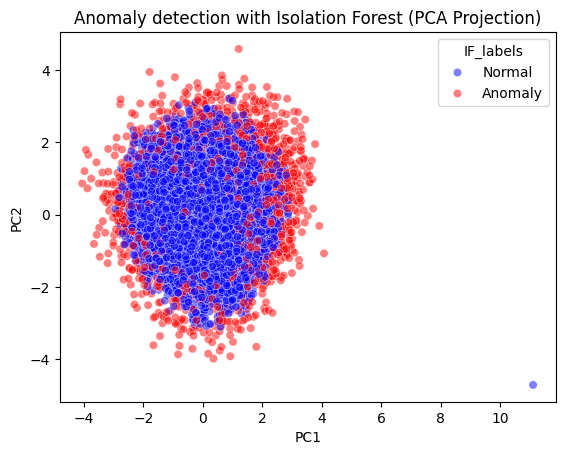

In [85]:
# Plot anomalies vs normal

# Create a scatter plot
sns.scatterplot(x='PC1', y='PC2', hue='IF_labels', data=df_IForest_PCA, palette={'Normal': 'blue', 'Anomaly': 'red'}, alpha=0.5)
plt.title('Anomaly detection with Isolation Forest (PCA Projection)')
plt.show()


# **Observations**

500 trees were used to randomly split the features and isolate the anomalies from normal data points.

Contamination factor of 5% was considered which gives us 977 anomalies.

Overlap of anomalies with IQR method gave us a figure of 393 and with One-class SVM gave us 868

A distinct visual of anomalies accumulating around the normal data was seen.

# **Comparing all three models**

In [86]:
# Create a comparison Dataframe

# Create a full index reference
full_index = df.index

# Initialise flags
comparison_df = pd.DataFrame(index=full_index)

# Create a comparison dataframe
comparison_df['IQR'] = full_index.isin(df_anomaly.index).astype(int)
comparison_df['OCSVM'] = full_index.isin(anomalies_OCSVM.index).astype(int)
comparison_df['IForest'] = full_index.isin(anomalies_IForest.index).astype(int)

comparison_df['Sum'] = comparison_df.sum(axis=1)

high_overlap = comparison_df[comparison_df['Sum'] >= 3]
anomalous_data = df.loc[high_overlap.index]

anomalous_data

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine rpm_flagged,Lub oil pressure_flagged,Fuel pressure_flagged,Coolant pressure_flagged,lub oil temp_flagged,Coolant temp_flagged,IQR_preds,svm_preds,svm_binary,overlap,PC1,PC2,svm_labels
144,3.627597,-1.572300,-0.843105,0.181408,2.927422,0.638962,1,0,0,0,1,0,1,-1,1,1,3.773251,1.952322,Anomaly
157,-0.961267,2.562869,4.125055,3.484390,-0.112710,-0.595022,0,0,1,1,0,0,1,-1,1,1,-3.484992,-0.358557,Anomaly
160,2.820435,0.587057,-0.163117,3.106627,0.380025,-0.765272,1,0,0,1,0,0,1,-1,1,1,0.176031,0.745479,Anomaly
249,0.795057,-0.546009,3.585316,3.283713,-0.971382,0.761739,0,0,1,1,0,0,1,-1,1,1,-1.273201,-1.463612,Anomaly
260,2.192643,-1.178967,-0.410326,3.075666,2.262722,0.396489,0,0,0,1,1,0,1,-1,1,1,2.424895,-0.178922,Anomaly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18713,-1.237795,2.005580,3.264813,2.637822,-0.013850,1.002075,0,0,1,1,0,0,1,-1,1,1,-1.950469,-0.772282,Anomaly
19185,-0.490423,-0.043952,3.832939,0.726240,3.528197,-1.107764,0,0,1,0,1,0,1,-1,1,1,-0.564640,1.088961,Anomaly
19328,-0.075631,0.599957,-0.550175,3.143009,2.608148,-1.474074,0,0,0,1,1,0,1,-1,1,1,0.277238,-0.154121,Anomaly
19343,2.555118,-1.096079,-0.035157,-1.032393,2.343389,1.556600,1,0,0,0,1,0,1,-1,1,1,3.295036,1.871425,Anomaly


# **Anomaly detection summary**

GOAL: To keep the proportion of flagged rows (outliers) between 1-5% of the entire dataset.

**Detection techniques**

*The following detection techniques were applied to the dataset.*

**IQR**

Highest number of anomalies were found in **Lubricating Oil temperature and Fuel pressure**

By keeping the threshold to **2 or more features**, we were able to keep the proportion of outliers within our goal.

**OneClass-SVM:**

Various combinations of hyperparameter values (gamma and nu) were considered to be within our goal of 1-5%.

gamma=0.1, nu=0.05 were finally considered for our analysis using this method which gave us 978 observations as anomalies.

Visual in 2D was created which showed us a very clear separation of anomalies around the cluster of normal data.

**Isolation Forest:**

Using around 500 trees and contamination level of 5% was considered to arrive to a figure of 977 anomalies.

Overlapping was conducted to check the agreement between this model and the other two. Results show that around 89% (868/977) anomalies from this model were also flagged by Oneclass SVM. In regards to overlapping with IQr method, Isolation forest only agrees with 40% (393/977) of its anomalies.

# **Comparison results (All three models)**

After comparing the results from all three models, 233 observations (1.2%) were flagged by all of them together, indicating high-anomaly confidence.

Isolation Forest provided the most consistent results indicated by strong overlap with other methods (especially OneClasss-SVM). The other factors that makes Isolation Forest better is its robust detection of anomalies (needs fewer number of splits) and lower sensitivity to feature scaling.